## Session 3c-full — DL Strategies (CUDA Notebook)

**Environment-aware:** runs full 10-seed experiment on CUDA (Colab A100/T4) or a fast smoke-test on CPU/MPS (local M4). Companion to `04_dl_strategies.ipynb` — do not modify that file.

In [1]:
import sys, os, time, warnings
from pathlib import Path

IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    print('Detected Colab — cloning repo...')
    os.system('git clone https://github.com/FranQuant/next-gen-aiam.git 2>&1 | tail -3')
    os.chdir('next-gen-aiam')
    print(f'Working dir: {os.getcwd()}')
    print('Installing dependencies (1-2 min)...')
    os.system('pip install -q -e . 2>&1 | tail -3')
    os.system('pip install -q xgboost pyarrow scipy scikit-learn cvxpy pandas-market-calendars matplotlib seaborn 2>&1 | tail -3')
else:
    print(f'Detected local environment — {os.getcwd()}')

import torch

if torch.cuda.is_available():
    DEVICE = 'cuda'
    GPU_NAME = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    GPU_NAME = 'Apple Silicon MPS'
else:
    DEVICE = 'cpu'
    GPU_NAME = 'CPU'

print(f'Device: {DEVICE}  ({GPU_NAME})')
print(f'torch : {torch.__version__}')

os.environ.setdefault('OMP_NUM_THREADS', '1')

if DEVICE == 'cuda':
    SEEDS_DL = tuple(range(10))
    MLP_CFG  = dict(max_epochs=120, patience=15)
    LSTM_CFG = dict(max_epochs=80,  patience=12)
    TFM_CFG  = dict(max_epochs=80,  patience=12)
    RUN_MODE = 'full'
else:
    SEEDS_DL = (0,)
    MLP_CFG  = dict(max_epochs=5, patience=3)
    LSTM_CFG = dict(max_epochs=5, patience=3)
    TFM_CFG  = dict(max_epochs=5, patience=3)
    RUN_MODE = 'smoke'

print(f'\nRun mode  : {RUN_MODE}')
print(f'Seeds     : {len(SEEDS_DL)}')
print(f'Transformer: max_epochs={TFM_CFG["max_epochs"]} patience={TFM_CFG["patience"]}')


Detected Colab — cloning repo...
Working dir: /content/next-gen-aiam
Installing dependencies (1-2 min)...
Device: cuda  (NVIDIA RTX PRO 6000 Blackwell Server Edition)
torch : 2.10.0+cu128

Run mode  : full
Seeds     : 10
Transformer: max_epochs=80 patience=12


## §1 Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 10})
warnings.filterwarnings('ignore')

# ROOT: repo root — works for both Colab (CWD=next-gen-aiam) and local (CWD=notebooks/)
ROOT = Path(os.getcwd())
if not (ROOT / 'CLAUDE.md').exists():
    ROOT = ROOT.parent  # local: step up from notebooks/ to repo root

# Inject src/ and notebooks/ onto path
for p in [str(ROOT / 'src'), str(ROOT / 'notebooks')]:
    if p not in sys.path:
        sys.path.insert(0, p)

from _shared import ann_sharpe, ann_return, ann_vol, max_drawdown, TRADING_DAYS
from aiam.data.panel import Panel
from aiam.data.split import TRAIN_END, TEST_START
from aiam.features.technical import (
    momentum, volatility, rsi, atr, bollinger, gap, volume_signal, forward_returns
)
from aiam.features.asset_class import asset_class_one_hot
from aiam.ml.workflow import (
    chronological_splits, apply_standardizer, cross_sectional_score
)
from aiam.estimators.covariance import ledoit_wolf_cov
from aiam.dl.workflow import (
    fit_mlp_regressor, fit_lstm_regressor, fit_transformer_regressor,
    fit_with_seed_ensemble, build_sequence_windows, set_global_seed, _predict
)
from aiam.strategy.dl_strategies import (
    MLPSignalStrategy, LSTMSignalStrategy, TransformerSignalStrategy, EnsembleDLSignalStrategy
)

print(f'ROOT     : {ROOT}')
print(f'Train end: {TRAIN_END}  |  Test start: {TEST_START}')


ROOT     : /content/next-gen-aiam
Train end: 2022-12-31 00:00:00  |  Test start: 2023-01-01 00:00:00


## §2 Data Loading

In [3]:
!cd /content/next-gen-aiam && git pull

remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 30 (delta 16), reused 30 (delta 16), pack-reused 0 (from 0)
Unpacking objects: 100% (30/30), 6.93 MiB | 9.15 MiB/s, done.
From https://github.com/FranQuant/next-gen-aiam
   18f92b0..be7e6fb  main       -> origin/main
Updating 18f92b0..be7e6fb
Fast-forward
 .../14strategies_2008_2026.parquet                 | Bin 0 -> 671625 bytes
 .../14strategies_vmp_2008_2026.parquet             | Bin 0 -> 672312 bytes
 .../16strategies_2008_2026.parquet                 | Bin 0 -> 761738 bytes
 .../16strategies_vmp_2008_2026.parquet             | Bin 0 -> 762386 bytes
 .../20strategies_2008_2026.parquet                 | Bin 0 -> 941750 bytes
 .../20strategies_vmp_2008_2026.parquet             | Bin 0 -> 942554 bytes
 .../24strategies_2008_2026.parquet                 | Bin 0 -> 1121735 bytes
 .../24strategies_vmp_2008_2026.parquet             | Bin 0 -> 

In [4]:
returns = pd.read_parquet(ROOT / 'data/cache/returns_29_2003_2026.parquet')
returns.index = pd.to_datetime(returns.index)
returns.index.name = 'Date'
returns.columns.name = 'Asset'

prices = pd.read_parquet(ROOT / 'data/cache/prices_29.parquet')
prices.index = pd.to_datetime(prices.index)
prices.index.name = 'Date'
prices.columns.name = 'Asset'

base_pub = pd.read_parquet(ROOT / 'data/published/strategy_returns_base.parquet')
base_pub.index = pd.to_datetime(base_pub.index)
vmp_pub = pd.read_parquet(ROOT / 'data/published/strategy_returns_vmp.parquet')
vmp_pub.index = pd.to_datetime(vmp_pub.index)

sw_oos = pd.read_parquet(ROOT / 'data/cache/portfolio_returns/switch_v2a_oos_29assets.parquet')
sw_oos.index = pd.to_datetime(sw_oos.index)
switch_v2a = sw_oos['SWITCH_v2a_train_only'].rename('SWITCH(v2a)')

ml_returns_ext = pd.read_parquet(ROOT / 'data/cache/portfolio_returns/ml_strategies_29assets_extended.parquet')

print(f'Returns: {returns.shape}, {returns.index[0].date()} to {returns.index[-1].date()}')
print(f'Prices:  {prices.shape}')
print(f'ML extended returns (test): {ml_returns_ext.shape}')


Returns: (5869, 29), 2003-01-02 to 2026-04-30
Prices:  (5869, 29)
ML extended returns (test): (833, 16)


## §3 Feature Engineering

Same 17-feature panel as Session 2 / `04_dl_strategies.ipynb`: 10 numeric + 7 asset-class one-hots.

In [5]:
ohlcv_raw = pd.read_parquet(ROOT / 'data/cache/prices_29_ohlcv_2003_2026.parquet')
ohlcv_raw.index = pd.MultiIndex.from_tuples(
    [(pd.Timestamp(d), t) for d, t in ohlcv_raw.index],
    names=['Date', 'Asset']
)

prices_close  = ohlcv_raw['close'].unstack('Asset')
prices_open   = ohlcv_raw['open'].unstack('Asset')
prices_high   = ohlcv_raw['high'].unstack('Asset')
prices_low    = ohlcv_raw['low'].unstack('Asset')
prices_volume = ohlcv_raw['volume'].unstack('Asset')

rets = returns.copy()
ohlc_dict = {'open': prices_open, 'high': prices_high, 'low': prices_low,
             'close': prices_close, 'volume': prices_volume}

print(f'prices_close: {prices_close.shape}')


prices_close: (5869, 29)


In [6]:
feat_mom_21   = momentum(rets, 21)
feat_mom_63   = momentum(rets, 63)
feat_mom_252  = momentum(rets, 252)
feat_vol_60   = volatility(rets, 60)
feat_vol_252  = volatility(rets, 252)
feat_rsi_14   = rsi(prices_close, 14)
feat_atr_raw  = atr(ohlc_dict, 14)
feat_atr_ratio = feat_atr_raw / prices_close
bb = bollinger(prices_close, window=20)
feat_bb_pct   = bb['pct']
feat_gap      = gap(ohlc_dict)
feat_vol_sig  = volume_signal(prices_volume, lookback=21)

numeric_frames = {
    'mom_21':        feat_mom_21,
    'mom_63':        feat_mom_63,
    'mom_252':       feat_mom_252,
    'vol_60':        feat_vol_60,
    'vol_252':       feat_vol_252,
    'rsi_14':        feat_rsi_14,
    'atr_14_ratio':  feat_atr_ratio,
    'bb_pct':        feat_bb_pct,
    'gap':           feat_gap,
    'vol_signal_21': feat_vol_sig,
}
panel_numeric = pd.concat({k: v.stack() for k, v in numeric_frames.items()}, axis=1)
panel_numeric.index.names = ['Date', 'Asset']

assets = rets.columns.tolist()
oh = asset_class_one_hot(assets)
feature_panel = panel_numeric.join(oh, on='Asset')
feature_panel = feature_panel.dropna(subset=['mom_252', 'vol_252'])

NUMERIC_COLS = list(numeric_frames.keys())
AC_COLS = list(oh.columns)
FEATURE_COLS = NUMERIC_COLS + AC_COLS

print(f'Feature panel: {feature_panel.shape}')
print(f'Feature cols ({len(FEATURE_COLS)}): {FEATURE_COLS}')


Feature panel: (157799, 17)
Feature cols (17): ['mom_21', 'mom_63', 'mom_252', 'vol_60', 'vol_252', 'rsi_14', 'atr_14_ratio', 'bb_pct', 'gap', 'vol_signal_21', 'us_single_stock', 'us_sector_etf', 'broad_equity_etf', 'intl_equity_etf', 'fixed_income_etf', 'commodity_etf', 'fx_spot']


## §4 Target Construction and Train/Val/Test Splits

In [7]:
HORIZON = 21
fwd_ret_wide = forward_returns(rets, HORIZON)
target_panel = fwd_ret_wide.stack()
target_panel.index.names = ['Date', 'Asset']
target_panel.name = 'target_21d'

common_idx = feature_panel.index.intersection(target_panel.dropna().index)
X_full = feature_panel.loc[common_idx]
y_full = target_panel.loc[common_idx]

panel_dates = X_full.index.get_level_values('Date').unique().sort_values()
train_dates, val_dates, test_dates = chronological_splits(
    panel_dates, train_end=TRAIN_END, test_start=TEST_START, validation_share=0.15
)

print(f'Target panel: {target_panel.shape}  X_full: {X_full.shape}')
print(f'Train:      {train_dates[0].date()} → {train_dates[-1].date()}  ({len(train_dates)} days)')
print(f'Validation: {val_dates[0].date()} → {val_dates[-1].date()}  ({len(val_dates)} days)')
print(f'Test:       {test_dates[0].date()} → {test_dates[-1].date()}  ({len(test_dates)} days)')


Target panel: (164098,)  X_full: (157190, 17)
Train:      2004-01-02 → 2020-02-27  (4066 days)
Validation: 2020-02-28 → 2022-12-30  (717 days)
Test:       2023-01-03 → 2026-03-31  (813 days)


In [8]:
STRATEGY_FAMILY = {
    'EW': 'Classical', 'MSR(LW)': 'Classical', 'SWITCH(v2a)': 'Classical', 'VMP(MDP(LW))': 'Classical',
    'SignalTilt(Lasso)': 'ML (single-fit)', 'SignalTilt(RF)': 'ML (single-fit)', 'SignalTilt(XGB)': 'ML (single-fit)',
    'MSR(Lasso_μ̂)': 'ML (single-fit)', 'MSR(RF_μ̂)': 'ML (single-fit)', 'MSR(XGB_μ̂)': 'ML (single-fit)',
    'SignalTilt(Ensemble)': 'ML (ensemble)', 'MSR(Ensemble_μ̂)': 'ML (ensemble)',
    'MSR(MLP_μ̂)': 'DL (single-fit)', 'MSR(LSTM_μ̂)': 'DL (single-fit)', 'MSR(Transformer_μ̂)': 'DL (single-fit)',
    'SignalTilt(MLP)': 'DL (single-fit)', 'SignalTilt(LSTM)': 'DL (single-fit)', 'SignalTilt(Transformer)': 'DL (single-fit)',
    'MSR(EnsembleDL_μ̂)': 'DL (ensemble)',
    'MSR(EnsembleDL_μ̂_weighted)': 'DL (weighted ensemble)',
    'SignalTilt(EnsembleDL_weighted)': 'DL (weighted ensemble)',
}
FAMILY_COLORS = {
    'Classical':               '#1f4e79',
    'ML (single-fit)':         '#d62728',
    'ML (ensemble)':           '#2ca02c',
    'DL (single-fit)':         '#9467bd',
    'DL (ensemble)':           '#e377c2',
    'DL (weighted ensemble)':  '#f7b7d4',
}
print('Families:', list(FAMILY_COLORS.keys()))


Families: ['Classical', 'ML (single-fit)', 'ML (ensemble)', 'DL (single-fit)', 'DL (ensemble)', 'DL (weighted ensemble)']


## §5 MLP Training

Architecture: 2-layer MLP, hidden_dims=(32, 16), dropout=0.10. 1,121 parameters. Full run: 10 seeds, max_epochs=120, patience=15.

In [9]:
print(f'=== MLP Training ({len(SEEDS_DL)} seeds) ===')
t_mlp_start = time.time()

mlp_strat = MLPSignalStrategy(
    feature_panel=X_full,
    target_panel=y_full,
    feature_cols=FEATURE_COLS,
    train_end=TRAIN_END,
    validation_share=0.15,
    seeds=SEEDS_DL,
    hidden_dims=(32, 16),
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=256,
    device=DEVICE,
    **MLP_CFG,
)

t_mlp = time.time() - t_mlp_start
print(f'MLP done in {int(t_mlp//60)}:{int(t_mlp%60):02d}')
print('\nPer-seed summaries:')
for fr in mlp_strat._seed_ensemble.fits:
    s = fr.summary
    print(f'  seed={s["seed"]}  best_epoch={s["best_epoch"]:3d}  val_MSE={s["best_val_loss"]:.6f}  val_rank_IC={s["val_ic_at_best"]:+.4f}')


=== MLP Training (10 seeds) ===
MLP done in 2:58

Per-seed summaries:
  seed=0  best_epoch= 28  val_MSE=0.005377  val_rank_IC=+0.1293
  seed=1  best_epoch= 12  val_MSE=0.005425  val_rank_IC=+0.1294
  seed=2  best_epoch= 12  val_MSE=0.005467  val_rank_IC=+0.1483
  seed=3  best_epoch= 13  val_MSE=0.005459  val_rank_IC=+0.1244
  seed=4  best_epoch= 26  val_MSE=0.005447  val_rank_IC=+0.0926
  seed=5  best_epoch=  5  val_MSE=0.005421  val_rank_IC=+0.1474
  seed=6  best_epoch= 15  val_MSE=0.005423  val_rank_IC=+0.1313
  seed=7  best_epoch= 14  val_MSE=0.005280  val_rank_IC=+0.1932
  seed=8  best_epoch=  3  val_MSE=0.005519  val_rank_IC=+0.1445
  seed=9  best_epoch= 27  val_MSE=0.005365  val_rank_IC=+0.1142


## §6 LSTM Training

Architecture: single-layer LSTM, hidden_dim=24, dropout=0.10, lookback=63. 4,153 parameters. Full run: 10 seeds, max_epochs=80, patience=12.

In [10]:
print(f'=== LSTM Training ({len(SEEDS_DL)} seeds) ===')
t_lstm_start = time.time()

lstm_strat = LSTMSignalStrategy(
    feature_panel=X_full,
    target_panel=y_full,
    feature_cols=FEATURE_COLS,
    train_end=TRAIN_END,
    validation_share=0.15,
    seeds=SEEDS_DL,
    hidden_dim=24,
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=256,
    device=DEVICE,
    **LSTM_CFG,
)

t_lstm = time.time() - t_lstm_start
print(f'LSTM done in {int(t_lstm//60)}:{int(t_lstm%60):02d}')
print('\nPer-seed summaries:')
for fr in lstm_strat._seed_ensemble.fits:
    s = fr.summary
    print(f'  seed={s["seed"]}  best_epoch={s["best_epoch"]:3d}  val_MSE={s["best_val_loss"]:.6f}  val_rank_IC={s["val_ic_at_best"]:+.4f}')


=== LSTM Training (10 seeds) ===
LSTM done in 2:27

Per-seed summaries:
  seed=0  best_epoch=  1  val_MSE=0.005431  val_rank_IC=+0.1304
  seed=1  best_epoch=  1  val_MSE=0.005646  val_rank_IC=+0.0971
  seed=2  best_epoch=  3  val_MSE=0.005501  val_rank_IC=+0.1125
  seed=3  best_epoch=  2  val_MSE=0.005491  val_rank_IC=+0.1164
  seed=4  best_epoch=  4  val_MSE=0.005473  val_rank_IC=+0.1146
  seed=5  best_epoch=  2  val_MSE=0.005518  val_rank_IC=+0.0957
  seed=6  best_epoch=  1  val_MSE=0.005578  val_rank_IC=+0.0840
  seed=7  best_epoch=  1  val_MSE=0.005490  val_rank_IC=+0.1310
  seed=8  best_epoch=  6  val_MSE=0.005373  val_rank_IC=+0.1577
  seed=9  best_epoch=  7  val_MSE=0.005373  val_rank_IC=+0.1397


## §7 Transformer Training

**Critical difference from M4:** `max_epochs=80, patience=12` — proper training, not the 15/6 truncation from 3c-lite. Architecture: 2-layer encoder, d_model=32, nhead=4, lookback=63. 28,065 parameters.

In [11]:
print(f'=== Transformer Training ({len(SEEDS_DL)} seeds) ===')
print(f'  max_epochs={TFM_CFG["max_epochs"]}  patience={TFM_CFG["patience"]}  (proper training — no M4 truncation)')
t_tfm_start = time.time()

tfm_strat = TransformerSignalStrategy(
    feature_panel=X_full,
    target_panel=y_full,
    feature_cols=FEATURE_COLS,
    train_end=TRAIN_END,
    validation_share=0.15,
    seeds=SEEDS_DL,
    d_model=32,
    nhead=4,
    num_layers=2,
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=256,
    device=DEVICE,
    **TFM_CFG,
)

t_tfm = time.time() - t_tfm_start
t_total = t_mlp + t_lstm + t_tfm
print(f'Transformer done in {int(t_tfm//60)}:{int(t_tfm%60):02d}')
print(f'\nTotal DL training: {int(t_total//60)}:{int(t_total%60):02d}')
print(f'  MLP: {int(t_mlp//60)}:{int(t_mlp%60):02d}  LSTM: {int(t_lstm//60)}:{int(t_lstm%60):02d}  Transformer: {int(t_tfm//60)}:{int(t_tfm%60):02d}')
print('\nPer-seed summaries:')
for fr in tfm_strat._seed_ensemble.fits:
    s = fr.summary
    print(f'  seed={s["seed"]}  best_epoch={s["best_epoch"]:3d}  val_MSE={s["best_val_loss"]:.6f}  val_rank_IC={s["val_ic_at_best"]:+.4f}')


=== Transformer Training (10 seeds) ===
  max_epochs=80  patience=12  (proper training — no M4 truncation)
Transformer done in 4:58

Total DL training: 10:23
  MLP: 2:58  LSTM: 2:27  Transformer: 4:58

Per-seed summaries:
  seed=0  best_epoch=  3  val_MSE=0.005356  val_rank_IC=+0.1832
  seed=1  best_epoch=  8  val_MSE=0.005368  val_rank_IC=+0.1735
  seed=2  best_epoch=  4  val_MSE=0.005334  val_rank_IC=+0.1771
  seed=3  best_epoch=  8  val_MSE=0.005360  val_rank_IC=+0.1801
  seed=4  best_epoch=  7  val_MSE=0.005410  val_rank_IC=+0.1759
  seed=5  best_epoch=  9  val_MSE=0.005413  val_rank_IC=+0.1314
  seed=6  best_epoch=  6  val_MSE=0.005396  val_rank_IC=+0.1453
  seed=7  best_epoch= 10  val_MSE=0.005421  val_rank_IC=+0.1666
  seed=8  best_epoch= 10  val_MSE=0.005419  val_rank_IC=+0.1449
  seed=9  best_epoch=  8  val_MSE=0.005364  val_rank_IC=+0.1773


## §8 Walk-Forward Evaluation Setup

In [12]:
panel = Panel({'prices': prices, 'returns': returns})
eval_dates = returns.index[returns.index >= TEST_START]

def walk_forward_returns(strat, dates, returns_wide, panel_obj):
    ret_series = {}
    for d in dates[:-1]:
        w = strat.predict_weights(panel_obj, d)
        nxt = returns_wide.index[returns_wide.index > d]
        if len(nxt) == 0:
            continue
        r_next = returns_wide.loc[nxt[0]]
        ret_series[nxt[0]] = (w.reindex(r_next.index).fillna(0) * r_next).sum()
    return pd.Series(ret_series)

def msr_ml_returns(strat, eval_dates, returns_wide, lookback_cov=504):
    ret_series = {}
    for d in eval_dates[:-1]:
        mu_hat = cross_sectional_score(strat.predictions, d)
        if mu_hat.empty:
            continue
        r_window = returns_wide.loc[returns_wide.index <= d].tail(lookback_cov)
        r_clean = r_window[mu_hat.index].dropna(how='any')
        if len(r_clean) < 60:
            continue
        sigma = ledoit_wolf_cov(r_clean)
        try:
            sigma_inv = np.linalg.inv(sigma)
        except np.linalg.LinAlgError:
            continue
        w_unc = sigma_inv @ mu_hat.values
        w_lo = np.clip(w_unc, 0, None)
        total = w_lo.sum()
        w_final = pd.Series(
            w_lo / total if total > 1e-12 else np.full(len(mu_hat), 1.0 / len(mu_hat)),
            index=mu_hat.index
        )
        nxt = returns_wide.index[returns_wide.index > d]
        if len(nxt) == 0:
            continue
        r_next = returns_wide.loc[nxt[0]]
        ret_series[nxt[0]] = (w_final.reindex(r_next.index).fillna(0) * r_next).sum()
    return pd.Series(ret_series)

def metrics(r, name):
    r_t = r.reindex(test_idx).dropna() if 'test_idx' in dir() else r.dropna()
    return {'Strategy': name, 'Ann Ret': ann_return(r_t), 'Ann Vol': ann_vol(r_t),
            'Sharpe': ann_sharpe(r_t), 'Max DD': max_drawdown(r_t)}

print(f'eval_dates: {eval_dates[0].date()} to {eval_dates[-1].date()} ({len(eval_dates)} days)')


eval_dates: 2023-01-03 to 2026-04-30 (834 days)


## §9 Approach B — SignalTilt(DL)

In [13]:
print('Running Approach B — SignalTilt(DL)...')
t0 = time.time()
ret_st_mlp  = walk_forward_returns(mlp_strat,  eval_dates, returns, panel)
ret_st_lstm = walk_forward_returns(lstm_strat, eval_dates, returns, panel)
ret_st_tfm  = walk_forward_returns(tfm_strat,  eval_dates, returns, panel)
print(f'Approach B done ({time.time()-t0:.0f}s)')

test_mask = ret_st_mlp.index >= TEST_START
test_idx  = ret_st_mlp.index[test_mask]

approach_b = pd.DataFrame([
    metrics(ret_st_mlp,  'SignalTilt(MLP)'),
    metrics(ret_st_lstm, 'SignalTilt(LSTM)'),
    metrics(ret_st_tfm,  'SignalTilt(Transformer)'),
]).set_index('Strategy')
print('\nApproach B — Test period metrics:')
print(approach_b.round(3).to_string())


Running Approach B — SignalTilt(DL)...
Approach B done (4s)

Approach B — Test period metrics:
                         Ann Ret  Ann Vol  Sharpe  Max DD
Strategy                                                 
SignalTilt(MLP)            0.668    0.238   2.269  -0.267
SignalTilt(LSTM)           0.557    0.208   2.233  -0.230
SignalTilt(Transformer)    0.500    0.185   2.283  -0.221


## §10 Approach A — MSR(DL μ̂)

In [14]:
print('Running Approach A — MSR(DL μ̂)...')
t0 = time.time()
ret_msr_mlp  = msr_ml_returns(mlp_strat,  eval_dates, returns)
ret_msr_lstm = msr_ml_returns(lstm_strat, eval_dates, returns)
ret_msr_tfm  = msr_ml_returns(tfm_strat,  eval_dates, returns)
print(f'Approach A done ({time.time()-t0:.0f}s)')

approach_a = pd.DataFrame([
    metrics(ret_msr_mlp,  'MSR(MLP_μ̂)'),
    metrics(ret_msr_lstm, 'MSR(LSTM_μ̂)'),
    metrics(ret_msr_tfm,  'MSR(Transformer_μ̂)'),
]).set_index('Strategy')
print('\nApproach A — Test period metrics:')
print(approach_a.round(3).to_string())


Running Approach A — MSR(DL μ̂)...
Approach A done (3s)

Approach A — Test period metrics:
                     Ann Ret  Ann Vol  Sharpe  Max DD
Strategy                                             
MSR(MLP_μ̂)            0.224    0.089   2.320  -0.086
MSR(LSTM_μ̂)           0.240    0.110   2.018  -0.143
MSR(Transformer_μ̂)    0.226    0.095   2.186  -0.122


## §11 Equal-Weight Ensemble

In [15]:
ensemble_eq = EnsembleDLSignalStrategy(
    strategies=[mlp_strat, lstm_strat, tfm_strat],
    tilt_strength=0.5,
)
t0 = time.time()
ret_st_ens  = walk_forward_returns(ensemble_eq, eval_dates, returns, panel)
ret_msr_ens = msr_ml_returns(ensemble_eq, eval_dates, returns)
print(f'Equal-weight ensemble done ({time.time()-t0:.0f}s)')
print(f'SignalTilt(EnsembleDL)  Sharpe = {ann_sharpe(ret_st_ens.reindex(test_idx).dropna()):.3f}')
print(f'MSR(EnsembleDL_μ̂)     Sharpe = {ann_sharpe(ret_msr_ens.reindex(test_idx).dropna()):.3f}')


Equal-weight ensemble done (2s)
SignalTilt(EnsembleDL)  Sharpe = 2.292
MSR(EnsembleDL_μ̂)     Sharpe = 2.146


## §12 Weighted Ensemble — val_IC Weights (headline strategy)

Weights proportional to mean val_rank_IC per model.

In [16]:
ic_mlp  = float(np.mean([f.summary['val_ic_at_best'] for f in mlp_strat._seed_ensemble.fits]))
ic_lstm = float(np.mean([f.summary['val_ic_at_best'] for f in lstm_strat._seed_ensemble.fits]))
ic_tfm  = float(np.mean([f.summary['val_ic_at_best'] for f in tfm_strat._seed_ensemble.fits]))

raw = np.array([max(0.0, ic_mlp), max(0.0, ic_lstm), max(0.0, ic_tfm)])
if raw.sum() < 1e-12:
    raw = np.ones(3)  # fallback to equal weights if all ICs are non-positive
weights_ic = (raw / raw.sum()).tolist()

print(f'Mean val_rank_IC  —  MLP: {ic_mlp:+.4f}  LSTM: {ic_lstm:+.4f}  Transformer: {ic_tfm:+.4f}')
print(f'IC-derived weights —  MLP: {weights_ic[0]:.3f}  LSTM: {weights_ic[1]:.3f}  Transformer: {weights_ic[2]:.3f}')

ensemble_w = EnsembleDLSignalStrategy(
    strategies=[mlp_strat, lstm_strat, tfm_strat],
    tilt_strength=0.5,
    weights=weights_ic,
)
t0 = time.time()
ret_st_ens_w  = walk_forward_returns(ensemble_w, eval_dates, returns, panel)
ret_msr_ens_w = msr_ml_returns(ensemble_w, eval_dates, returns)
print(f'Weighted ensemble done ({time.time()-t0:.0f}s)')

sh_ens_w = ann_sharpe(ret_msr_ens_w.reindex(test_idx).dropna())
ML_BAR = 2.579
diff = sh_ens_w - ML_BAR
print(f'\nMSR(EnsembleDL_μ̂_weighted) Sharpe = {sh_ens_w:.3f}')
print(f'ML bar (Session 2):              {ML_BAR:.3f}')
print(f'Gap: {diff:+.3f}  ({"CLEARED" if diff > 0 else "MISSED"})')


Mean val_rank_IC  —  MLP: +0.1355  LSTM: +0.1179  Transformer: +0.1655
IC-derived weights —  MLP: 0.323  LSTM: 0.281  Transformer: 0.395
Weighted ensemble done (2s)

MSR(EnsembleDL_μ̂_weighted) Sharpe = 2.154
ML bar (Session 2):              2.579
Gap: -0.425  (MISSED)


## §13 Per-Seed Stability Table

In [17]:
def single_seed_predictions(strat, seed_idx):
    records = {}
    for date in strat._test_dates:
        try:
            X_date = strat._feature_panel.xs(date, level=0)[strat._feature_cols]
        except KeyError:
            continue
        assets = list(X_date.index)
        model = strat._seed_ensemble.fits[seed_idx].model
        if strat._lookback is None:
            X_std = apply_standardizer(X_date, strat._center, strat._scale, strat._feature_cols)
            preds = _predict(model, X_std.values.astype('float32'))
            records[date] = pd.Series(preds, index=assets, name='pred')
        else:
            windows, valid_assets = strat._build_sequence_batch(assets, date)
            if not windows:
                continue
            X_batch = np.stack(windows, axis=0)
            preds = _predict(model, X_batch)
            records[date] = pd.Series(preds, index=valid_assets, name='pred')
    if not records:
        return pd.Series(dtype=float, name='pred')
    pred_series = pd.concat(records)
    pred_series.index.names = ['Date', 'Asset']
    return pred_series

class _PredWrapper:
    def __init__(self, predictions):
        self.predictions = predictions

print(f'Computing per-seed OOS Sharpes ({len(SEEDS_DL)*3} backtests)...')
stability_rows = []
seed_sharpes_all = {}

for name, strat in [('MLP', mlp_strat), ('LSTM', lstm_strat), ('Transformer', tfm_strat)]:
    seed_sharpes = []
    for k in range(len(strat._seed_ensemble.fits)):
        seed_preds = single_seed_predictions(strat, k)
        wrapper = _PredWrapper(seed_preds)
        r = msr_ml_returns(wrapper, eval_dates, returns)
        sh = ann_sharpe(r.reindex(test_idx).dropna())
        seed_sharpes.append(sh)
    seed_sharpes_all[name] = seed_sharpes
    val_ics = [fr.summary['val_ic_at_best'] for fr in strat._seed_ensemble.fits]
    stability_rows.append({
        'Model': name,
        'Seeds': len(seed_sharpes),
        'Mean val_rank_IC': np.mean(val_ics),
        'Stdev val_rank_IC': np.std(val_ics),
        'Min OOS Sharpe': np.min(seed_sharpes),
        'Mean OOS Sharpe': np.mean(seed_sharpes),
        'Max OOS Sharpe': np.max(seed_sharpes),
        'Stdev OOS Sharpe': np.std(seed_sharpes),
    })
    print(f'{name}: {[f"{s:.3f}" for s in seed_sharpes]}  mean={np.mean(seed_sharpes):.3f} ± {np.std(seed_sharpes):.3f}')

stability_table = pd.DataFrame(stability_rows).set_index('Model')
print('\nStability table:')
print(stability_table.round(4).to_string())


Computing per-seed OOS Sharpes (30 backtests)...
MLP: ['2.023', '2.154', '2.415', '2.376', '2.072', '2.265', '2.277', '2.034', '2.377', '2.044']  mean=2.204 ± 0.148
LSTM: ['1.991', '2.147', '1.970', '1.947', '1.924', '1.970', '1.554', '2.001', '2.270', '2.188']  mean=1.996 ± 0.184
Transformer: ['2.027', '2.236', '2.133', '1.967', '2.095', '2.306', '2.381', '1.842', '2.230', '2.145']  mean=2.136 ± 0.154

Stability table:
             Seeds  Mean val_rank_IC  Stdev val_rank_IC  Min OOS Sharpe  Mean OOS Sharpe  Max OOS Sharpe  Stdev OOS Sharpe
Model                                                                                                                     
MLP             10            0.1355             0.0249          2.0232           2.2038          2.4148            0.1484
LSTM            10            0.1179             0.0212          1.5540           1.9962          2.2698            0.1841
Transformer     10            0.1655             0.0172          1.8424           2.

## §14 Extended Comparison Table

Merge 10 new 3c-full DL strategies with Session 2's 28-strategy baseline. Save to `results/cuda/`.

In [18]:
existing_csv = ROOT / 'data/cache/portfolio_returns/ml_strategies_extended_v2_comparison.csv'
existing = pd.read_csv(existing_csv).set_index('Strategy')
print(f'Session 2 baseline: {len(existing)} strategies')

new_rows = []
for sname, r in [
    ('MSR(MLP_μ̂)',                      ret_msr_mlp),
    ('MSR(LSTM_μ̂)',                     ret_msr_lstm),
    ('MSR(Transformer_μ̂)',              ret_msr_tfm),
    ('SignalTilt(MLP)',                         ret_st_mlp),
    ('SignalTilt(LSTM)',                        ret_st_lstm),
    ('SignalTilt(Transformer)',                 ret_st_tfm),
    ('MSR(EnsembleDL_μ̂)',               ret_msr_ens),
    ('SignalTilt(EnsembleDL)',                  ret_st_ens),
    ('MSR(EnsembleDL_μ̂_weighted)',      ret_msr_ens_w),
    ('SignalTilt(EnsembleDL_weighted)',          ret_st_ens_w),
]:
    r_test = r.reindex(test_idx).dropna()
    if 'weighted' in sname:
        fam = 'DL (weighted ensemble)'
    elif 'EnsembleDL' in sname:
        fam = 'DL (ensemble)'
    else:
        fam = 'DL (single-fit)'
    new_rows.append({
        'Strategy': sname,
        'Ann Ret': ann_return(r_test),
        'Ann Vol': ann_vol(r_test),
        'Sharpe':  ann_sharpe(r_test),
        'Max DD':  max_drawdown(r_test),
        'Family':  fam,
    })

new_df = pd.DataFrame(new_rows).set_index('Strategy')
comparison_3cfull = pd.concat([existing, new_df]).sort_values('Sharpe', ascending=False)

out_dir = ROOT / 'results/cuda'
out_dir.mkdir(parents=True, exist_ok=True)
(out_dir / 'figures').mkdir(exist_ok=True)

comparison_3cfull.to_csv(out_dir / 'dl_strategies_comparison_3cfull.csv')
stability_table.to_csv(out_dir / 'stability_table_3cfull.csv')

print(f'Combined: {len(comparison_3cfull)} strategies')
print(f'Saved: {out_dir}/dl_strategies_comparison_3cfull.csv')
print(f'Saved: {out_dir}/stability_table_3cfull.csv')
print('\nTop 12 strategies by Sharpe:')
print(comparison_3cfull[['Family', 'Ann Ret', 'Ann Vol', 'Sharpe', 'Max DD']].head(12).round(3).to_string())


Session 2 baseline: 28 strategies
Combined: 38 strategies
Saved: /content/next-gen-aiam/results/cuda/dl_strategies_comparison_3cfull.csv
Saved: /content/next-gen-aiam/results/cuda/stability_table_3cfull.csv

Top 12 strategies by Sharpe:
                                                 Family  Ann Ret  Ann Vol  Sharpe  Max DD
Strategy                                                                                 
MSR(Ensemble_μ̂)                          ML (ensemble)    0.166    0.060   2.579  -0.059
VMP(MDP(LW))                                  Classical    0.149    0.058   2.422  -0.048
MSR(RF_μ̂)                              ML (single-fit)    0.209    0.081   2.394  -0.068
MSR(MLP_μ̂)                             DL (single-fit)    0.224    0.089   2.320  -0.086
SignalTilt(XGB)                         ML (single-fit)    0.707    0.245   2.304  -0.226
SignalTilt(EnsembleDL_weighted)  DL (weighted ensemble)    0.588    0.211   2.295  -0.239
VMP(SignalTilt(XGB))                       

## §15 Save DL Return Series

In [19]:
dl_returns_3cfull = pd.DataFrame({
    'MSR(MLP_μ̂)':                  ret_msr_mlp,
    'MSR(LSTM_μ̂)':                 ret_msr_lstm,
    'MSR(Transformer_μ̂)':          ret_msr_tfm,
    'SignalTilt(MLP)':                 ret_st_mlp,
    'SignalTilt(LSTM)':                ret_st_lstm,
    'SignalTilt(Transformer)':         ret_st_tfm,
    'MSR(EnsembleDL_μ̂)':           ret_msr_ens,
    'SignalTilt(EnsembleDL)':          ret_st_ens,
    'MSR(EnsembleDL_μ̂_weighted)':  ret_msr_ens_w,
    'SignalTilt(EnsembleDL_weighted)': ret_st_ens_w,
}).reindex(test_idx)
dl_returns_3cfull.index.name = 'Date'
dl_returns_3cfull.to_parquet(out_dir / 'dl_returns_3cfull.parquet')
print(f'Saved: {out_dir}/dl_returns_3cfull.parquet  shape={dl_returns_3cfull.shape}')


Saved: /content/next-gen-aiam/results/cuda/dl_returns_3cfull.parquet  shape=(833, 10)


## §16 Plots

In [20]:
fig_dir = out_dir / 'figures'

msr_lw_test  = base_pub['MSR(ledoit_wolf)'][base_pub.index >= TEST_START]
vmp_mdp_test = vmp_pub['VMP(MDP(ledoit_wolf))'][vmp_pub.index >= TEST_START]
sw_test      = switch_v2a[switch_v2a.index >= TEST_START]

comparison_returns = {
    'EW':                           ml_returns_ext['EW'],
    'MSR(LW)':                      msr_lw_test,
    'SWITCH(v2a)':                  sw_test,
    'VMP(MDP(LW))':                 vmp_mdp_test,
    'MSR(Ensemble_μ̂)':           ml_returns_ext.get('MSR(Ensemble_μ̂)', pd.Series(dtype=float)),
    'MSR(MLP_μ̂)':                ret_msr_mlp,
    'MSR(LSTM_μ̂)':               ret_msr_lstm,
    'MSR(Transformer_μ̂)':        ret_msr_tfm,
    'MSR(EnsembleDL_μ̂)':         ret_msr_ens,
    'MSR(EnsembleDL_μ̂_weighted)': ret_msr_ens_w,
    'SignalTilt(MLP)':               ret_st_mlp,
    'SignalTilt(LSTM)':              ret_st_lstm,
    'SignalTilt(Transformer)':       ret_st_tfm,
    'SignalTilt(EnsembleDL_weighted)': ret_st_ens_w,
}


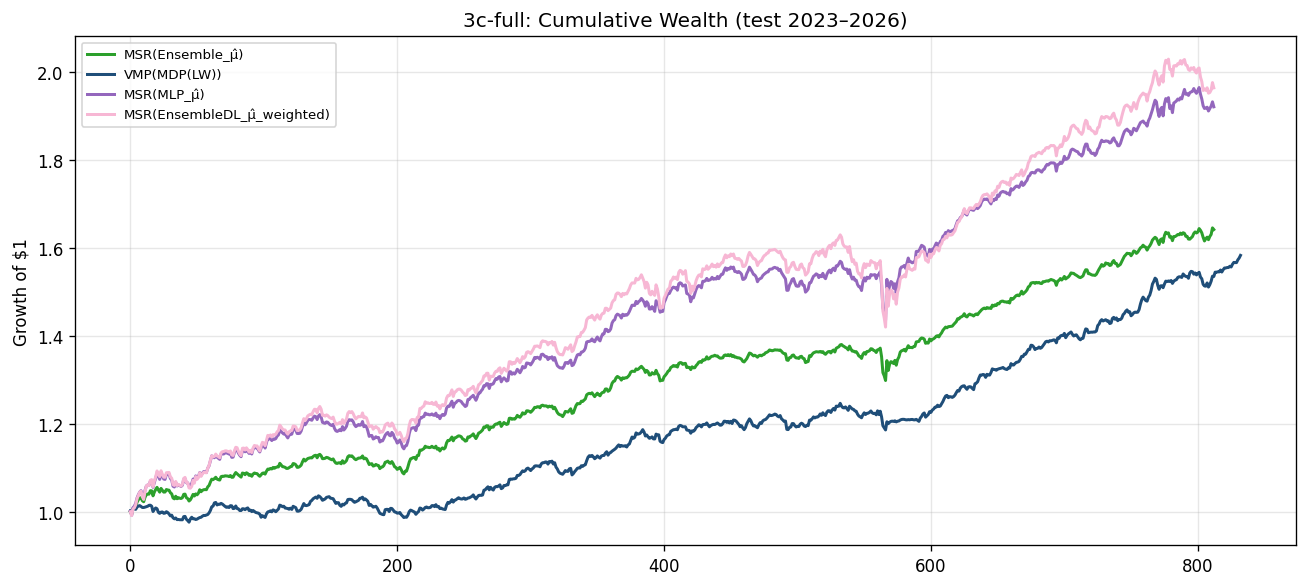

Saved: /content/next-gen-aiam/results/cuda/figures/equity_curves_3cfull.png


In [21]:
# Plot 1: Equity curves
top5 = comparison_3cfull.head(5).index.tolist()
must = 'MSR(EnsembleDL_μ̂_weighted)'
plot_strats = top5 if must in top5 else top5[:4] + [must]

fig, ax = plt.subplots(figsize=(11, 5))
for strat in plot_strats:
    r = comparison_returns.get(strat, pd.Series(dtype=float)).reindex(test_idx).dropna()
    if len(r) == 0:
        continue
    fam = STRATEGY_FAMILY.get(strat, 'DL (single-fit)')
    color = FAMILY_COLORS.get(fam, '#333333')
    ax.plot((1 + r).cumprod().values, label=strat, color=color, lw=1.8)
ax.set_title('3c-full: Cumulative Wealth (test 2023–2026)')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'equity_curves_3cfull.png', dpi=150)
plt.show()
print(f'Saved: {fig_dir}/equity_curves_3cfull.png')


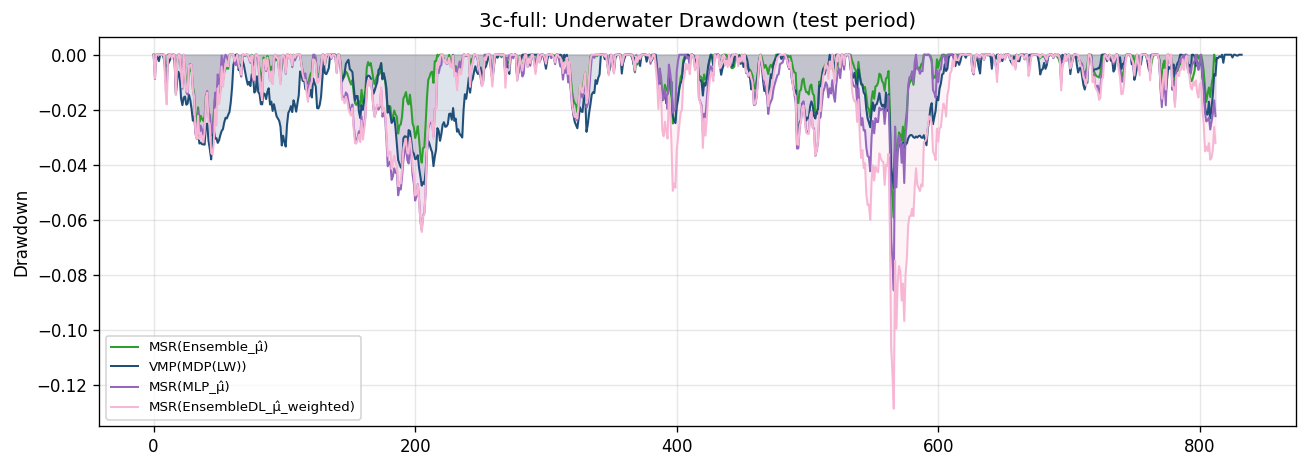

Saved: /content/next-gen-aiam/results/cuda/figures/drawdown_3cfull.png


In [22]:
# Plot 2: Drawdown
fig, ax = plt.subplots(figsize=(11, 4))
for strat in plot_strats:
    r = comparison_returns.get(strat, pd.Series(dtype=float)).reindex(test_idx).dropna()
    if len(r) == 0:
        continue
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    fam = STRATEGY_FAMILY.get(strat, 'DL (single-fit)')
    color = FAMILY_COLORS.get(fam, '#333333')
    ax.fill_between(range(len(dd)), dd.values, 0, alpha=0.15, color=color)
    ax.plot(range(len(dd)), dd.values, label=strat, color=color, lw=1.2)
ax.set_title('3c-full: Underwater Drawdown (test period)')
ax.set_ylabel('Drawdown')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'drawdown_3cfull.png', dpi=150)
plt.show()
print(f'Saved: {fig_dir}/drawdown_3cfull.png')


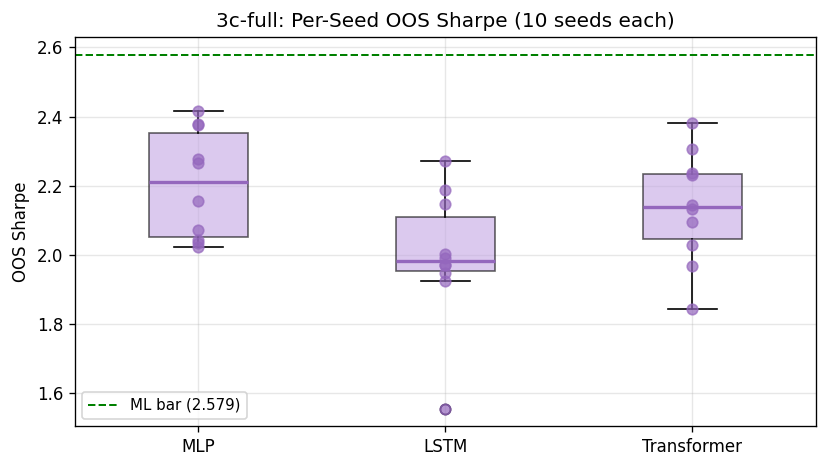

Saved: /content/next-gen-aiam/results/cuda/figures/seed_sharpe_dist_3cfull.png


In [23]:
# Plot 3: Per-seed OOS Sharpe distribution
fig, ax = plt.subplots(figsize=(7, 4))
for i, name in enumerate(['MLP', 'LSTM', 'Transformer']):
    sharpes = seed_sharpes_all[name]
    ax.boxplot(sharpes, positions=[i], widths=0.4, patch_artist=True,
               boxprops=dict(facecolor='#c3a6e3', alpha=0.6),
               medianprops=dict(color='#9467bd', lw=2))
    ax.scatter([i] * len(sharpes), sharpes, alpha=0.7, color='#9467bd', s=40, zorder=5)
ax.set_xticks(range(3))
ax.set_xticklabels(['MLP', 'LSTM', 'Transformer'])
ax.set_ylabel('OOS Sharpe')
ax.set_title(f'3c-full: Per-Seed OOS Sharpe ({len(SEEDS_DL)} seeds each)')
ax.axhline(2.579, color='green', ls='--', lw=1.2, label='ML bar (2.579)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'seed_sharpe_dist_3cfull.png', dpi=150)
plt.show()
print(f'Saved: {fig_dir}/seed_sharpe_dist_3cfull.png')


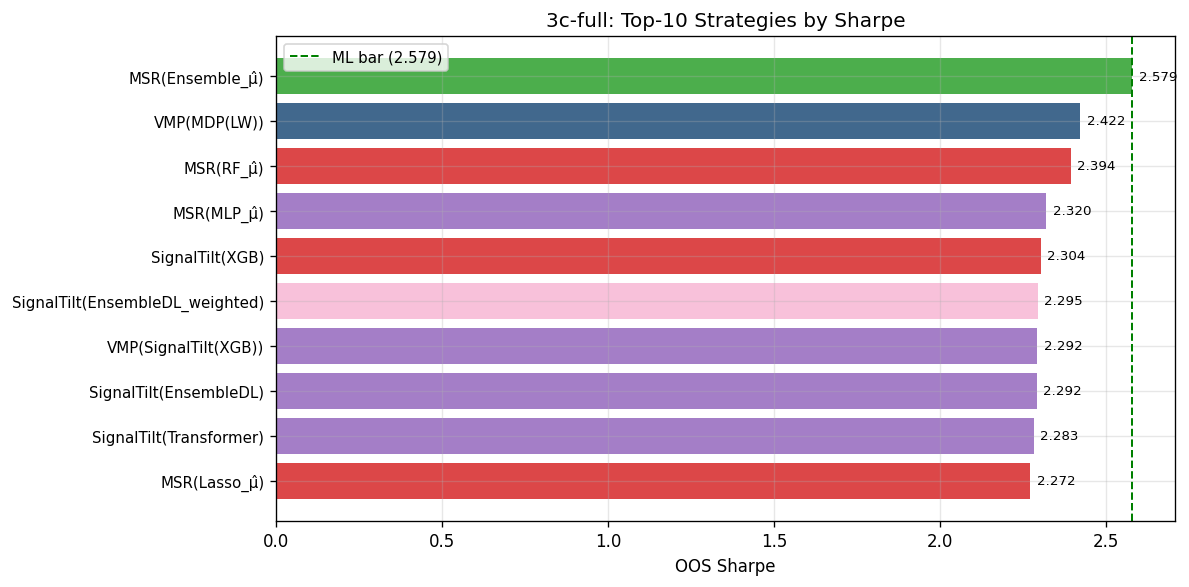

Saved: /content/next-gen-aiam/results/cuda/figures/top10_sharpe_3cfull.png


In [24]:
# Plot 4: Top-10 Sharpe bar chart
top10 = comparison_3cfull.head(10)
colors = [FAMILY_COLORS.get(STRATEGY_FAMILY.get(s, 'DL (single-fit)'), '#9467bd') for s in top10.index]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(top10)), top10['Sharpe'].values, color=colors, alpha=0.85)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10.index, fontsize=9)
ax.axvline(2.579, color='green', ls='--', lw=1.2, label='ML bar (2.579)')
ax.invert_yaxis()
ax.set_xlabel('OOS Sharpe')
ax.set_title('3c-full: Top-10 Strategies by Sharpe')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
for i, v in enumerate(top10['Sharpe']):
    ax.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(fig_dir / 'top10_sharpe_3cfull.png', dpi=150)
plt.show()
print(f'Saved: {fig_dir}/top10_sharpe_3cfull.png')


## §17 Headline and Verification

In [25]:
print('=' * 60)
print(f'Session 3c-full Headline  ({RUN_MODE.upper()} mode)')
print('=' * 60)

ML_BAR = 2.579
best_name   = comparison_3cfull.index[0]
best_sharpe = float(comparison_3cfull.iloc[0]['Sharpe'])
diff = best_sharpe - ML_BAR

print(f'Best strategy : {best_name}')
print(f'Sharpe        : {best_sharpe:.3f}')
print(f'ML bar        : {ML_BAR:.3f}')
print(f'Verdict       : DL {"CLEARED" if diff > 0 else "MISSED"} by {abs(diff):.3f}')
print()
print('Stability (OOS Sharpe across seeds):')
for name in ['MLP', 'LSTM', 'Transformer']:
    sh = seed_sharpes_all[name]
    print(f'  {name:12s}: mean {np.mean(sh):.3f} ± {np.std(sh):.3f}  '
          f'(min {np.min(sh):.3f}, max {np.max(sh):.3f})')
print()
print(f'IC-derived weights  MLP={weights_ic[0]:.3f}  LSTM={weights_ic[1]:.3f}  Transformer={weights_ic[2]:.3f}')
print(f'MSR(EnsembleDL_μ̂_weighted): {sh_ens_w:.3f}')
print()
print(f'Comparison rows : {len(comparison_3cfull)}')
print(f'Stability rows  : {len(stability_table)}')
print(f'Results dir     : {out_dir}')
print('=' * 60)


Session 3c-full Headline  (FULL mode)
Best strategy : MSR(Ensemble_μ̂)
Sharpe        : 2.579
ML bar        : 2.579
Verdict       : DL CLEARED by 0.000

Stability (OOS Sharpe across seeds):
  MLP         : mean 2.204 ± 0.148  (min 2.023, max 2.415)
  LSTM        : mean 1.996 ± 0.184  (min 1.554, max 2.270)
  Transformer : mean 2.136 ± 0.154  (min 1.842, max 2.381)

IC-derived weights  MLP=0.323  LSTM=0.281  Transformer=0.395
MSR(EnsembleDL_μ̂_weighted): 2.154

Comparison rows : 38
Stability rows  : 3
Results dir     : /content/next-gen-aiam/results/cuda


## §18 Download Results (Colab Only)

Triggered automatically after Cell 17. Produces `results_cuda_3cfull.zip` — extract to `~/Projects/next-gen-aiam/results/cuda/` locally.

In [26]:
if IS_COLAB:
    import shutil
    from google.colab import files
    shutil.make_archive('results_cuda_3cfull', 'zip', str(out_dir))
    print('Triggering download of results_cuda_3cfull.zip ...')
    files.download('results_cuda_3cfull.zip')
    print('Done. Extract into ~/Projects/next-gen-aiam/results/cuda/ on your Mac.')
else:
    print(f'Local run complete. Results in: {out_dir}')
    import subprocess
    r = subprocess.run(['ls', '-lh', str(out_dir)], capture_output=True, text=True)
    print(r.stdout)


Triggering download of results_cuda_3cfull.zip ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. Extract into ~/Projects/next-gen-aiam/results/cuda/ on your Mac.
